In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e10/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e10/train.csv
/kaggle/input/competitions/playground-series-s6e10/test.csv


In [3]:
TRAIN = pd.read_csv("/kaggle/input/competitions/playground-series-s6e10/train.csv")
TEST = pd.read_csv("/kaggle/input/competitions/playground-series-s6e10/test.csv")
SUBMIT = pd.read_csv("/kaggle/input/competitions/playground-series-s6e10/test.csv")

## Dataset metadata information

In [4]:
TRAIN = TRAIN.drop(columns=["id"], errors="ignore")
TRAIN.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,36,694,4,4,4,3,1,4,1,1,...,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
1,56,651,5,5,5,5,5,4,4,5,...,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,True
2,31,1371,3,4,2,5,3,3,3,3,...,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
3,10,1616,3,5,3,3,3,3,3,3,...,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,False
4,23,481,3,4,3,4,5,3,5,5,...,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,False


In [5]:
TRAIN.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699635 entries, 0 to 699634
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Age                                699635 non-null  int64  
 1   Flight Distance                    699635 non-null  int64  
 2   Inflight wifi service              699635 non-null  int64  
 3   Departure/Arrival time convenient  699635 non-null  int64  
 4   Ease of Online booking             699635 non-null  int64  
 5   Gate location                      699635 non-null  int64  
 6   Food and drink                     699635 non-null  int64  
 7   Online boarding                    699635 non-null  int64  
 8   Seat comfort                       699635 non-null  int64  
 9   Inflight entertainment             699635 non-null  int64  
 10  On-board service                   699635 non-null  int64  
 11  Leg room service                   6996

In [6]:
TRAIN.nunique()

Age                                    75
Flight Distance                      3474
Inflight wifi service                   6
Departure/Arrival time convenient       6
Ease of Online booking                  6
Gate location                           6
Food and drink                          6
Online boarding                         6
Seat comfort                            6
Inflight entertainment                  6
On-board service                        6
Leg room service                        6
Baggage handling                        5
Checkin service                         6
Cleanliness                             6
Departure Delay in Minutes            167
Arrival Delay in Minutes              168
Gender                                  2
Customer Type                           2
Type of Travel                          2
Class                                   3
satisfaction                            2
dtype: int64

In [7]:
for col in TRAIN.columns:
    print(col, "==>", TRAIN[col].unique())

Age ==> [36 56 31 10 23 34 57 60 44 32 28 26 24 48 49 41 45 22 42  9 30 55 29 20
 14 58 51 16 27 54 39 65 37 59 17 53 50 15 43 40 35 46 33 62 52 38 21 18
  8 47 61 25 70 63 19 69 12  7 68 11 13 67 64 66 72 77 71 78 73 74 75 80
 76 79 85]
Flight Distance ==> [ 694  651 1371 ... 3002 1154 2048]
Inflight wifi service ==> [4 5 3 1 2 0]
Departure/Arrival time convenient ==> [4 5 3 2 0 1]
Ease of Online booking ==> [4 5 2 3 1 0]
Gate location ==> [3 5 4 2 1 0]
Food and drink ==> [1 5 3 4 2 0]
Online boarding ==> [4 3 2 1 5 0]
Seat comfort ==> [1 4 3 5 2 0]
Inflight entertainment ==> [1 5 3 4 2 0]
On-board service ==> [3 5 4 2 1 0]
Leg room service ==> [4 5 3 0 1 2]
Baggage handling ==> [4 5 3 2 1]
Checkin service ==> [3 4 5 1 2 0]
Cleanliness ==> [1 3 5 2 4 0]
Departure Delay in Minutes ==> [  0   5  25  24   3   6   2   1  17  10   4  12  47  42  18   8   7  15
  21   9  26  35  52  19  31  22  13 152  29  36  16  14  37  41  28  50
  33  11  34  40  45  23 153  20  27  38  44  43  39  30 2

In [8]:
num_col = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
target = "satisfaction"
cat_col = [col for col in TRAIN.columns if col not in num_col and col != target]

In [9]:
TRAIN.isna().sum()

Age                                    0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             292
Gender                                 0
Customer Type                          0
Type of Travel                         0
Class                                  0
satisfaction                           0
dtype: int64

## Statistical tests

In [10]:
# Target class distribution before rows having NaN
display(pd.concat([
    TRAIN[target].value_counts(),
    TRAIN[target].value_counts(normalize=True).rename("percentage")
], axis=1))

,count,percentage
satisfaction,,
False,389296,0.556427
True,310339,0.443573


In [11]:
# Inspecting the variable "Arrival Delay in Minutes" (presence of NaN)

variable = "Arrival Delay in Minutes"

valid_rows = TRAIN.dropna(subset=[variable])
after_counts = valid_rows[target].value_counts(normalize=True).rename("After Dropping NaNs")
display(after_counts.to_frame())

# Since the target class distributions are almost identical, we may consider dropping those rows having nan values

TRAIN = TRAIN.dropna(subset=["Arrival Delay in Minutes"]).reset_index(drop=True)

,After Dropping NaNs
satisfaction,
False,0.556394
True,0.443606


In [12]:
Y = TRAIN[target].astype(int)
# Y.value_counts(normalize=True)

In [13]:
# Numerical statistics
def skewness_type(skewness):
    if abs(skewness) < 0.1:
        return "Approximately symmetric"
    elif skewness > 0:
        return "Right-skewed"
    else:
        return "Left-skewed"


num_stats = TRAIN[num_col].describe().T

num_stats = num_stats.rename(columns={"50%": "median", "25%":"Q1", "75%": "Q3"})

num_stats["IQR"] = num_stats["Q3"] - num_stats["Q1"]

num_stats["skewness"] = TRAIN[num_col].skew().apply(
    lambda x: f"{x:.2f} : {skewness_type(x)}"
)
display(num_stats)

,count,mean,std,min,Q1,median,Q3,max,IQR,skewness
Age,699343.0,39.002531,13.800828,7.0,27.0,40.0,50.0,85.0,23.0,-0.05 : Approximately symmetric
Flight Distance,699343.0,1353.798525,954.450464,67.0,631.0,954.0,1814.0,4983.0,1183.0,1.08 : Right-skewed
Departure Delay in Minutes,699343.0,1.173596,5.964274,0.0,0.0,0.0,0.0,489.0,0.0,12.85 : Right-skewed
Arrival Delay in Minutes,699343.0,1.134280,5.749304,0.0,0.0,0.0,0.0,491.0,0.0,13.32 : Right-skewed


In [14]:
x_yes = (Y == 1).sum()
x_no = len(Y) - x_yes

t3 = Y.value_counts().reset_index(name="count")

t3["%age"] = t3["count"] / len(Y) * 100
display(t3)

imbr = max(x_yes, x_no) / min(x_yes, x_no)
print("\n\nClass imbalance ratio=", imbr)

,satisfaction,count,%age
0,0,389110,55.639364
1,1,310233,44.360636




Class imbalance ratio= 1.2542508372739198


In [15]:
from scipy.stats import mannwhitneyu, chi2_contingency, spearmanr
check = lambda p: "Reject H0" if p < 0.05 else "Fail to reject H0"

In [16]:
# Numerical columns relationship with target hypothesis testing
def run_mannwhitneyu(df, y, cols):
    H = {"Feature": [], "Test statistic": [], "p-value": [], "Decision": []}

    for c in cols:
        yes_group = df.loc[y == 1, c]
        no_group = df.loc[y == 0, c]
        
        t_stat, p = mannwhitneyu(yes_group, no_group)
        
        H["Feature"].append(c)
        H["Test statistic"].append(t_stat)
        H["p-value"].append(p)
        H["Decision"].append(check(p))

    nsa = pd.DataFrame(H)
    nsa["Test statistic"] = nsa["Test statistic"].round(5)
    nsa["p-value"] = nsa["p-value"].round(5)

    display(nsa)
    # return nsa

run_mannwhitneyu(TRAIN, Y, num_col)

,Feature,Test statistic,p-value,Decision
0,Age,7.537233e+10,0.0,Reject H0
1,Flight Distance,8.396851e+10,0.0,Reject H0
2,Departure Delay in Minutes,5.932784e+10,0.0,Reject H0
3,Arrival Delay in Minutes,5.839591e+10,0.0,Reject H0


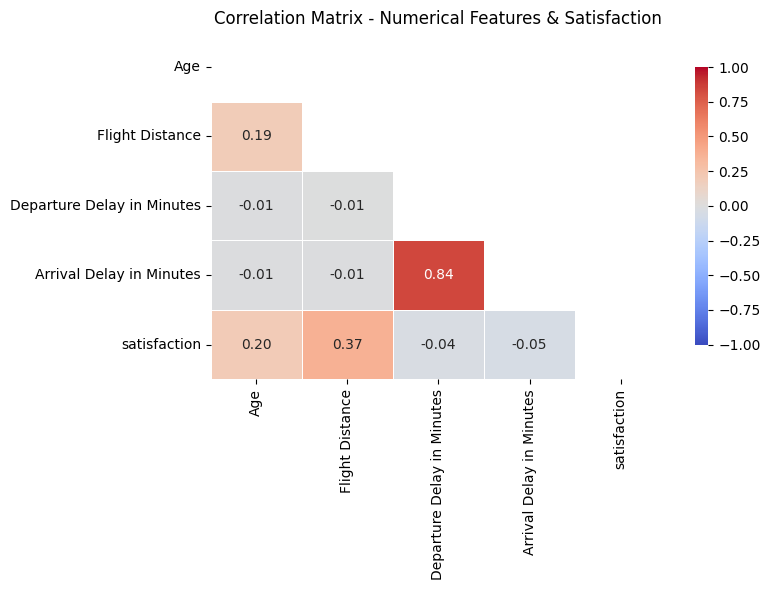

In [17]:
# 1. Compute Pearson (or method='spearman') correlation matrix
corr_matrix = TRAIN[num_col + ['satisfaction']].corr(method='pearson')

target_corr = (
    corr_matrix[['satisfaction']]
    .drop(index='satisfaction')
    .iloc[
        corr_matrix[['satisfaction']]
        .drop(index='satisfaction')['satisfaction']
        .abs()
        .argsort()[::-1]
    ]
    .round(4)
)

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmax=1,
    vmin=-1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Correlation Matrix - Numerical Features & Satisfaction", fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
# Categorical columns association with target hypothesis testing

# Nominal columns
nom_cat_col = ["Gender", "Customer Type", "Type of Travel"]
H1 = {"Feature": [], "chi2_statistic": [], "p-value": [], "Decision": []}

for i, c in enumerate(nom_cat_col):
    contingency_table = pd.crosstab(
        TRAIN[c], 
        TRAIN[target], 
        colnames=[target], 
        rownames=[c]
    ).rename_axis(index=None, columns=None)
    
    chi2_stat, p, dof, expected = chi2_contingency(contingency_table)

    # print(f"{i + 1}. Feature ==> {c}")
    # display(contingency_table)
    # print("\n\n")

    H1["Feature"].append(c)
    H1["chi2_statistic"].append(chi2_stat)
    H1["p-value"].append(p)
    H1["Decision"].append(check(p))

csa = pd.DataFrame(H1)

csa["chi2_statistic"] = csa["chi2_statistic"].round(5)
csa["p-value"] = csa["p-value"].round(5)

display(csa)

,Feature,chi2_statistic,p-value,Decision
0,Gender,86.64098,0.0,Reject H0
1,Customer Type,35456.77939,0.0,Reject H0
2,Type of Travel,138106.13076,0.0,Reject H0


In [19]:
TRAIN['Class'] = TRAIN['Class'].replace({'Eco': 0, 'Eco Plus': 1, 'Business': 2}).astype(int)
ord_cat_col = [col for col in cat_col if col not in nom_cat_col]

# print(len(ord_cat_col) + len(nom_cat_col))
run_mannwhitneyu(TRAIN, Y, ord_cat_col)

/tmp/ipykernel_58/1580254337.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  TRAIN['Class'] = TRAIN['Class'].replace({'Eco': 0, 'Eco Plus': 1, 'Business': 2}).astype(int)


,Feature,Test statistic,p-value,Decision
0,Inflight wifi service,7.999063e+10,0.0,Reject H0
1,Departure/Arrival time convenient,5.715462e+10,0.0,Reject H0
2,Ease of Online booking,7.351741e+10,0.0,Reject H0
3,Gate location,6.200850e+10,0.0,Reject H0
4,Food and drink,7.497477e+10,0.0,Reject H0
5,Online boarding,1.014458e+11,0.0,Reject H0
6,Seat comfort,8.837843e+10,0.0,Reject H0
7,Inflight entertainment,8.987471e+10,0.0,Reject H0
8,On-board service,8.442010e+10,0.0,Reject H0
9,Leg room service,8.301767e+10,0.0,Reject H0


In [20]:
def run_spearmanr(df, y, cols):
    H = {"Feature": [], "Spearman Correlation": [], "p-value": [], "Decision": []}
    
    for c in cols:
        corr, p = spearmanr(df[c], y)
        
        H["Feature"].append(c)
        H["Spearman Correlation"].append(corr)
        H["p-value"].append(p)
        H["Decision"].append(check(p))

    ssa = pd.DataFrame(H)
    ssa["Spearman Correlation"] = ssa["Spearman Correlation"].round(5)
    ssa["p-value"] = ssa["p-value"].round(5)

    ssa = ssa.iloc[ssa["Spearman Correlation"].abs().argsort()[::-1]].reset_index(drop=True)
    display(ssa)

run_spearmanr(TRAIN, Y, ord_cat_col)

,Feature,Spearman Correlation,p-value,Decision
0,Online boarding,0.60201,0.0,Reject H0
1,Class,0.54975,0.0,Reject H0
2,Inflight entertainment,0.43298,0.0,Reject H0
3,Seat comfort,0.41297,0.0,Reject H0
4,On-board service,0.35415,0.0,Reject H0
5,Cleanliness,0.33464,0.0,Reject H0
6,Leg room service,0.33243,0.0,Reject H0
7,Inflight wifi service,0.28697,0.0,Reject H0
8,Baggage handling,0.28012,0.0,Reject H0
9,Checkin service,0.24085,0.0,Reject H0


## EDA

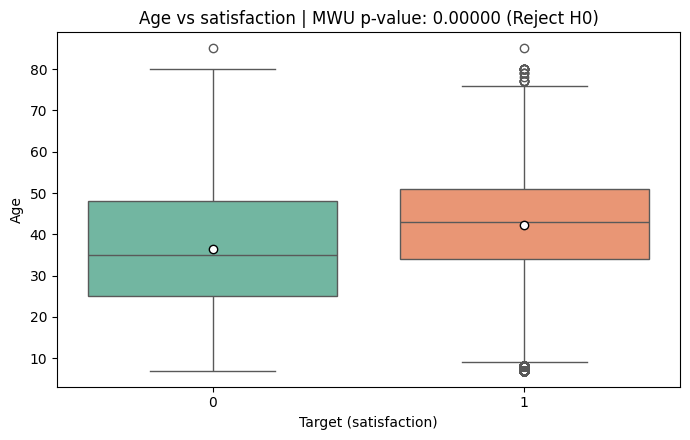

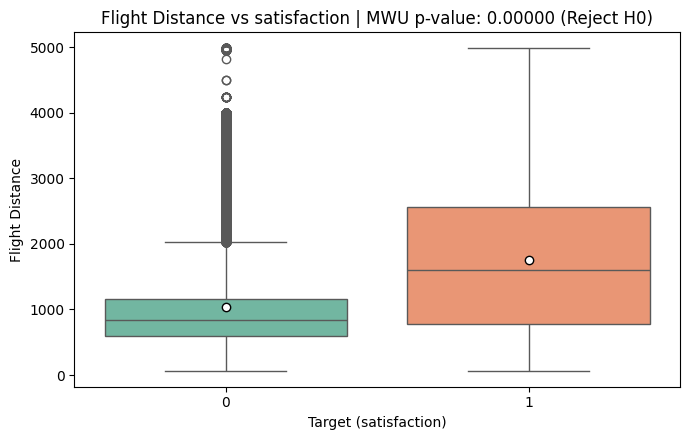

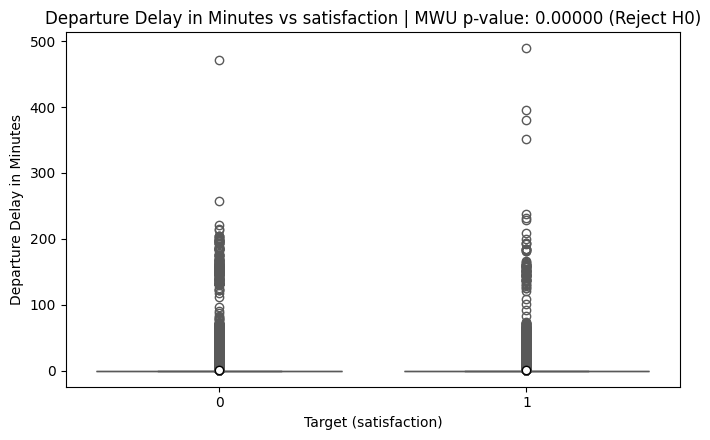

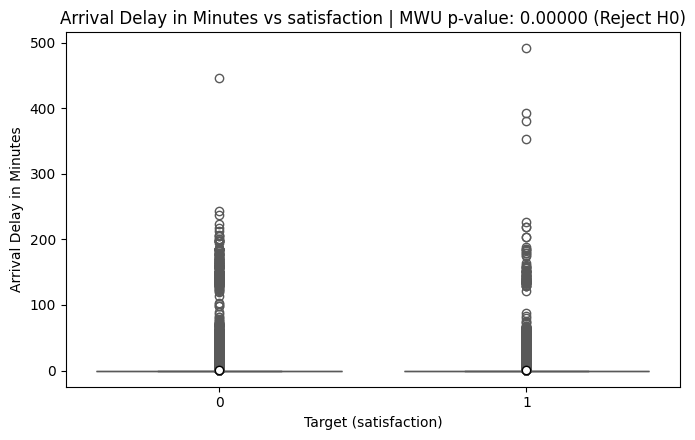

In [27]:
def plot_feature_boxplot(feature_series, target_series):
    df = pd.DataFrame({"feature": feature_series, "target": target_series}).dropna()
    name = feature_series.name or "Feature"
    target = target_series.name or "Target"
    g1, g0 = (df.loc[df.target == i, "feature"] for i in [1, 0])
    _, p = mannwhitneyu(g1, g0)
    decision = "Reject H0" if p < 0.05 else "Fail to reject H0"

    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.boxplot(data=df, x="target", y="feature", hue="target",
                palette="Set2", showmeans=True, legend=False, ax=ax,
                meanprops={"marker": "o", "markerfacecolor": "white",
                           "markeredgecolor": "black"})
    ax.set(title=f"{name} vs {target} | MWU p-value: {p:.5f} ({decision})",
           xlabel=f"Target ({target})", ylabel=name)
    plt.tight_layout()
    plt.show()

for col in num_col:
    plot_feature_boxplot(TRAIN[col], Y)

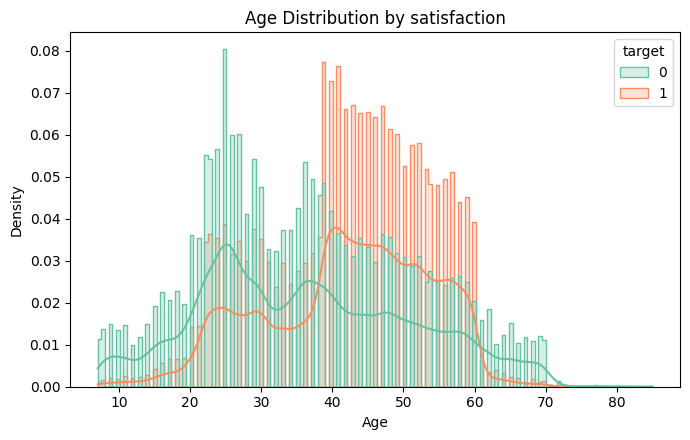

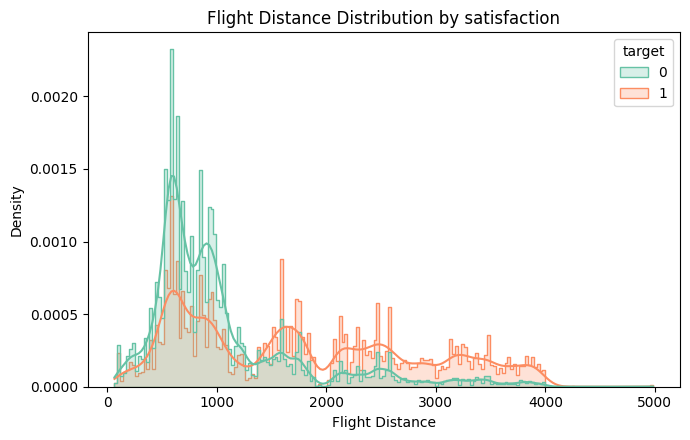

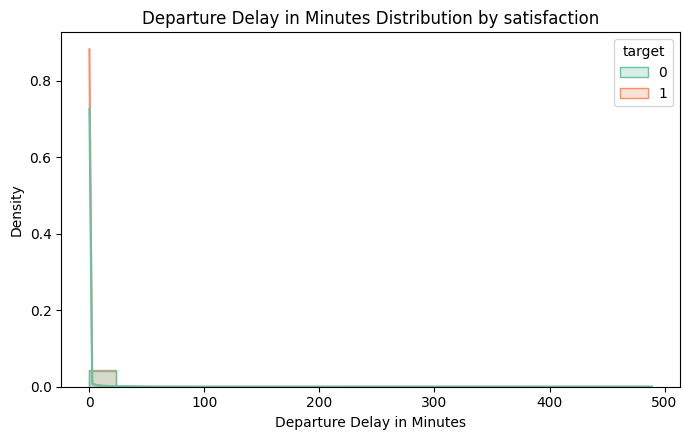

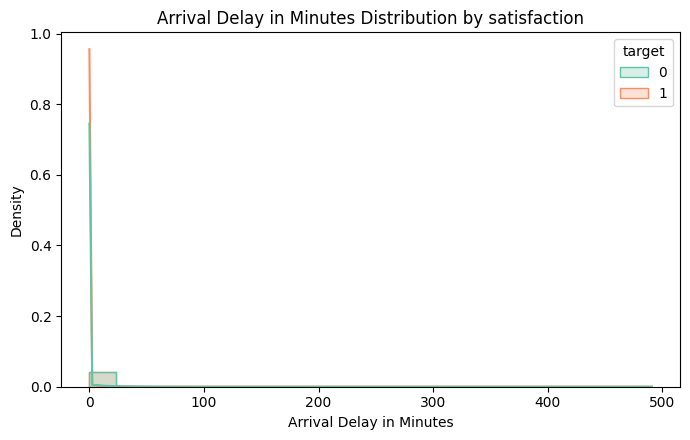

In [28]:

def plot_feature_distribution(feature_series, target_series):
    df = pd.DataFrame({"feature": feature_series, "target": target_series}).dropna()
    name = feature_series.name or "Feature"
    target = target_series.name or "Target"

    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.histplot(data=df, x="feature", hue="target", kde=True,
                 stat="density", common_norm=False, element="step",
                 palette="Set2", ax=ax)
    ax.set(title=f"{name} Distribution by {target}",
           xlabel=name, ylabel="Density")
    plt.tight_layout()
    plt.show()

for col in num_col:
    plot_feature_distribution(TRAIN[col], Y)

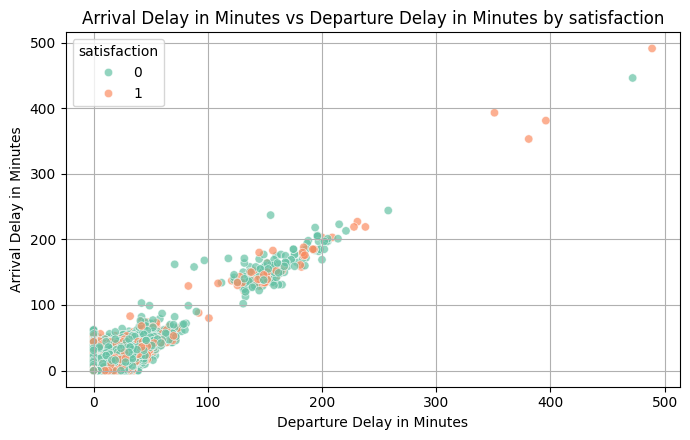

In [30]:
def plot_feature_scatter(feature_x, feature_y, target_series):
    df = pd.DataFrame({
        feature_x.name or "Feature X": feature_x,
        feature_y.name or "Feature Y": feature_y,
        target_series.name or "Target": target_series
    }).dropna()

    x, y, target = df.columns

    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.scatterplot(data=df, x=x, y=y, hue=target, palette="Set2",
                    alpha=0.7, ax=ax)
    ax.set_title(f"{y} vs {x} by {target}")
    plt.tight_layout()
    plt.grid(True)
    plt.show()

plot_feature_scatter(TRAIN['Departure Delay in Minutes'], TRAIN['Arrival Delay in Minutes'], Y)